# Red neuronal para reconocer dígitos a mano con Keras

¡Asegúrate de estar usando TensorFlow 1.9 o superior!

Keras es una API de nivel superior dentro de TensorFlow que simplifica mucho las cosas. No solo es más fácil de usar, sino que también es más fácil de ajustar.

Primero importaremos todo lo que necesitamos, lo cual inicializará Keras como efecto secundario:

In [2]:
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD

Cargaremos el conjunto de datos MNIST. Hay 60.000 muestras de entrenamiento y 10.000 muestras de prueba.

In [ ]:
import numpy as np

(mnist_train_images, mnist_train_labels), (mnist_test_images, mnist_test_labels) = mnist.load_data()
# Mostrar imagen de ejemplo
imagen_seleccionada = mnist_train_images[0]
np.set_printoptions(threshold=np.inf)
print(f"Etiqueta de la imagen: {mnist_train_labels[0]}")
print("Matriz completa de la primera imagen (valores de píxel 0-255):\n")
print(imagen_seleccionada)

Necesitamos convertir los datos explícitamente al formato que Keras / TensorFlow espera. reshape() lo transforma en un vector de 784 elementos. Dividimos los datos de la imagen entre 255 para normalizarlos en el rango de 0 a 1, después de convertirlos a valores de punto flotante.

In [ ]:
train_images = mnist_train_images.reshape(60000, 784)
#print(train_images[1])
test_images = mnist_test_images.reshape(10000, 784)
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')
train_images /= 255
#print(train_images[1])
test_images /= 255

Ahora convertiremos las etiquetas del 0 al 9 al formato "one-hot" (codificación one-hot). Piensa en la codificación one-hot como una representación binaria de los datos de la etiqueta, es decir, qué número pretendía representar cada muestra de escritura a mano.

Matemáticamente, one-hot representa una dimensión por cada posible valor de etiqueta. Cada dimensión se establece en el valor 0, excepto la dimensión "correcta", que se establece en 1. Por ejemplo, el vector de etiqueta que representa el número 1 sería [0, 1, 0, 0, 0, 0, 0, 0, 0, 0] (recuerda que empezamos a contar desde 0). Es simplemente un formato que está optimizado para la forma en que se aplican las etiquetas durante el entrenamiento.

Por lo tanto, los datos de la etiqueta de entrenamiento son un tensor con la forma [60.000, 10]: 60.000 imágenes de prueba, cada una asociada con 10 valores binarios que indican si la imagen representa o no un número dado del 0 al 9.


In [4]:
train_labels = keras.utils.to_categorical(mnist_train_labels, 10)
print(type(train_labels))
test_labels = keras.utils.to_categorical(mnist_test_labels, 10)

<class 'numpy.ndarray'>


Revisemos una de las imágenes de entrenamiento para comprobar que sea correcta:

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


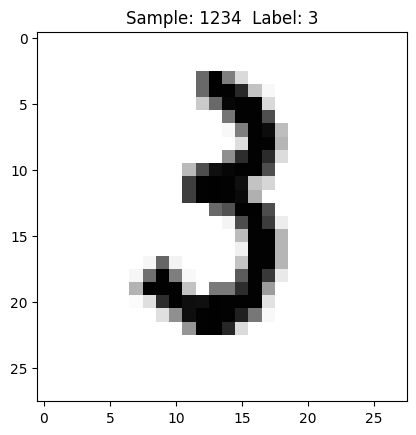

In [5]:
import matplotlib.pyplot as plt

def display_sample(num):
    #Print the one-hot array of this sample's label 
    print(train_labels[num])  
    #Print the label converted back to a number
    label = train_labels[num].argmax(axis=0)
    #Reshape the 768 values to a 28x28 image
    image = train_images[num].reshape([28,28])
    plt.title('Sample: %d  Label: %d' % (num, label))
    plt.imshow(image, cmap=plt.get_cmap('gray_r'))
    plt.show()
    
display_sample(1234)

Podemos configurar las capas de esta manera. La capa de entrada de 784 características (features) se conecta a una capa Sgimoid de 512 nodos (o neuronas), que luego pasa a 10 nodos a los que se aplica Softmax. Función de Softmax: Convierte los valores numéricos brutos (llamados logits) de los 10 nodos en una distribución de probabilidad donde la suma total es 1. El nodo con la probabilidad más alta es la predicción final de la red. Ej. y = [0.1, 0.8, 0.1] (10% Gato, 80% Perro, 10% Pájaro)

In [6]:
from tensorflow.keras.layers import Input
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(512, activation='sigmoid'))
model.add(Dense(10, activation='softmax'))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Configurar nuestro optimizador y función de pérdida es igual de sencillo. Usaremos el optimizador SGD aquí. Otras opciones incluyen Adagrad, SGD, Adam, Adamax y Nadam. Ver https://keras.io/optimizers/

In [8]:
model.compile(loss='mean_squared_error', 
              optimizer=SGD(),
              metrics=['accuracy'])

Entrenar nuestro modelo es también solo una línea de código con Keras.

In [9]:
history = model.fit(train_images, train_labels,
                    batch_size=100,
                    epochs=30,
                    verbose=2,
                    validation_data=(test_images, test_labels))

Epoch 1/30
600/600 - 4s - 6ms/step - accuracy: 0.1078 - loss: 0.0913 - val_accuracy: 0.1572 - val_loss: 0.0899
Epoch 2/30
600/600 - 2s - 4ms/step - accuracy: 0.1974 - loss: 0.0895 - val_accuracy: 0.2359 - val_loss: 0.0891
Epoch 3/30
600/600 - 3s - 5ms/step - accuracy: 0.2465 - loss: 0.0888 - val_accuracy: 0.2707 - val_loss: 0.0885
Epoch 4/30
600/600 - 3s - 5ms/step - accuracy: 0.2799 - loss: 0.0883 - val_accuracy: 0.2913 - val_loss: 0.0880
Epoch 5/30
600/600 - 3s - 5ms/step - accuracy: 0.3000 - loss: 0.0878 - val_accuracy: 0.3180 - val_loss: 0.0874
Epoch 6/30
600/600 - 3s - 5ms/step - accuracy: 0.3194 - loss: 0.0872 - val_accuracy: 0.3354 - val_loss: 0.0869
Epoch 7/30
600/600 - 3s - 5ms/step - accuracy: 0.3390 - loss: 0.0866 - val_accuracy: 0.3434 - val_loss: 0.0863
Epoch 8/30
600/600 - 3s - 5ms/step - accuracy: 0.3442 - loss: 0.0860 - val_accuracy: 0.3614 - val_loss: 0.0856
Epoch 9/30
600/600 - 3s - 5ms/step - accuracy: 0.3553 - loss: 0.0854 - val_accuracy: 0.3727 - val_loss: 0.0849
E

In [10]:
score = model.evaluate(test_images, test_labels, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.06629104912281036
Test accuracy: 0.6223999857902527


Como antes, visualicemos cuando se equivocó.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


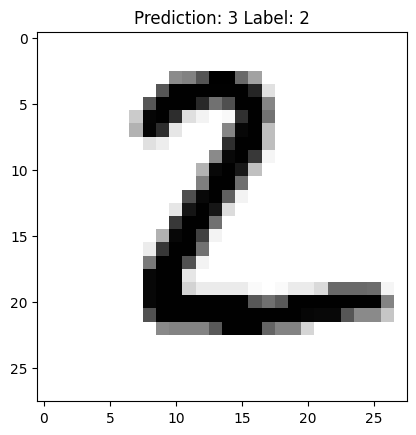

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


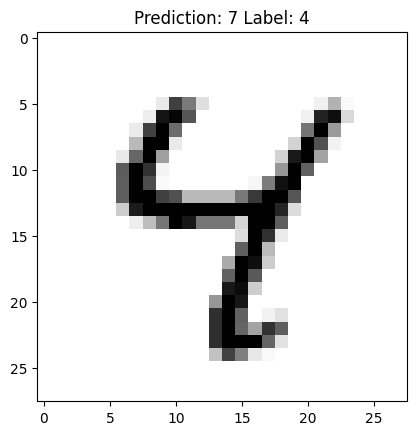

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


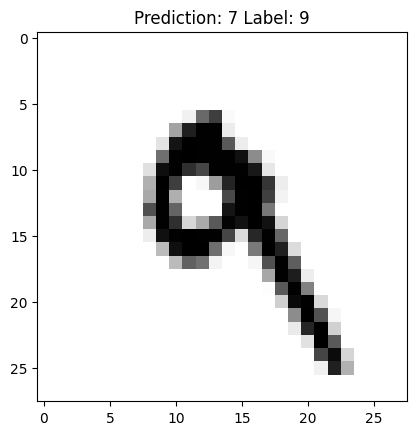

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


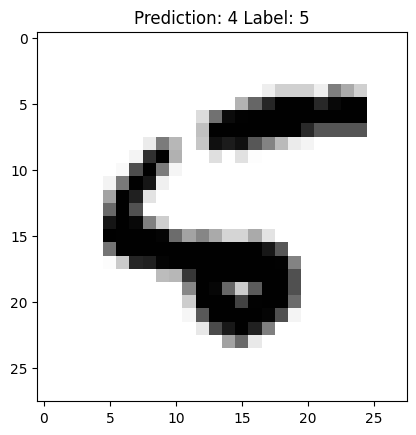

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


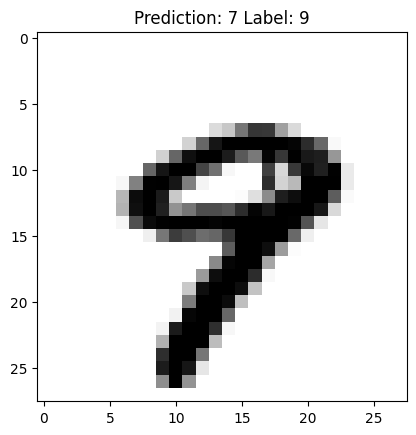

In [11]:
for x in range(10):
    test_image = test_images[x,:].reshape(1,784)
    predicted_cat = model.predict(test_image).argmax()
    label = test_labels[x].argmax()
    if (predicted_cat != label):
        plt.title('Prediction: %d Label: %d' % (predicted_cat, label))
        plt.imshow(test_image.reshape([28,28]), cmap=plt.get_cmap('gray_r'))
        plt.show()